In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df=pd.read_csv('/content/Weather_Data.csv')
df.head()

,Date,City,Temperature (°C),Humidity (%),Wind Speed (km/h),Weather Condition
0,2021-12-07,West Rachel,38.9,75,29.0,Rainy
1,2020-08-30,Port Jill,37.7,67,2.7,Rainy
2,2025-04-19,Priscillafurt,6.8,86,8.6,Cloudy
3,2021-05-01,Jacobmouth,22.1,63,12.2,Sunny
4,2020-05-07,Moranhaven,30.2,39,0.6,Cloudy


In [26]:
#preprocessing
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Weather Condition']=le.fit_transform(df['Weather Condition'])
df.head()

,Date,City,Temperature (°C),Humidity (%),Wind Speed (km/h),Weather Condition
0,2021-12-07,West Rachel,38.9,75,29.0,1
1,2020-08-30,Port Jill,37.7,67,2.7,1
2,2025-04-19,Priscillafurt,6.8,86,8.6,0
3,2021-05-01,Jacobmouth,22.1,63,12.2,3
4,2020-05-07,Moranhaven,30.2,39,0.6,0


In [30]:
print("First 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nDescriptive Statistics")
print(df.describe())

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\nMean Values")
print(df[numeric_cols].mean())

print("\nMedian Values")
print(df[numeric_cols].median())

print("\nMode Values")
print(df[numeric_cols].mode().iloc[0])

print("\nStandard Deviation")
print(df[numeric_cols].std())

print("\nCorrelation Matrix")
print(df[numeric_cols].corr())

First 5 Rows
         Date           City  Temperature (°C)  Humidity (%)  \
0  2021-12-07    West Rachel              38.9            75   
1  2020-08-30      Port Jill              37.7            67   
2  2025-04-19  Priscillafurt               6.8            86   
3  2021-05-01     Jacobmouth              22.1            63   
4  2020-05-07     Moranhaven              30.2            39   

   Wind Speed (km/h)  Weather Condition  
0               29.0                  1  
1                2.7                  1  
2                8.6                  0  
3               12.2                  3  
4                0.6                  0  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               100 non-null    object 
 1   City               100 non-null    object 
 2   Temperature (°C)   100 non-nu

In [31]:
for col in numeric_cols:
    print(f"\nAnalysis for {col}")
    print(f"Average Value: {df[col].mean()}")
    print(f"Maximum Value: {df[col].max()}")
    print(f"Minimum Value: {df[col].min()}")

    if df[col].mean() > df[col].median():
        print("Positive skew observed")
    elif df[col].mean() < df[col].median():
        print("Negative skew observed")
    else:
        print("Data appears symmetric")


Analysis for Temperature (°C)
Average Value: 16.506999999999998
Maximum Value: 39.7
Minimum Value: -9.3
Negative skew observed

Analysis for Humidity (%)
Average Value: 54.9
Maximum Value: 96
Minimum Value: 10
Negative skew observed

Analysis for Wind Speed (km/h)
Average Value: 13.217
Maximum Value: 29.7
Minimum Value: 0.1
Positive skew observed

Analysis for Weather Condition
Average Value: 1.55
Maximum Value: 3
Minimum Value: 0
Negative skew observed


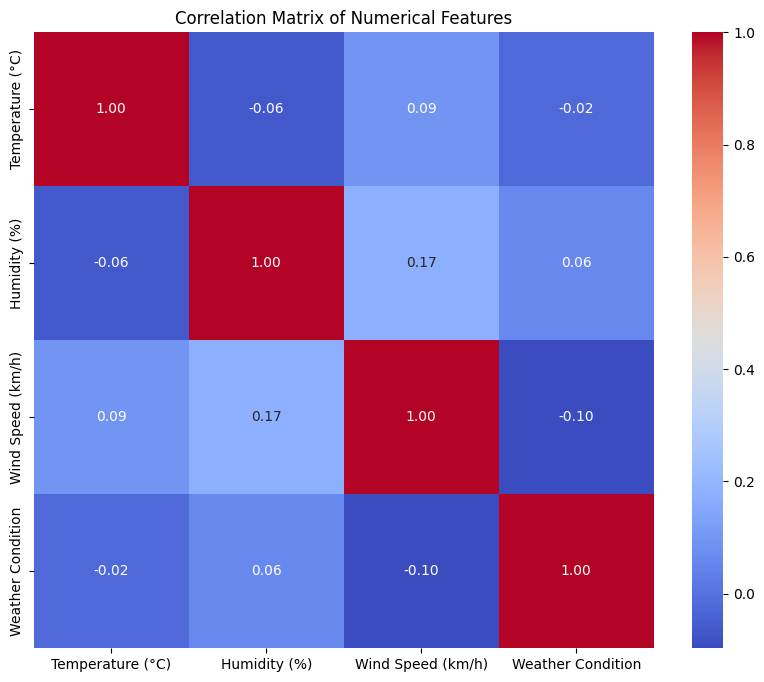

In [21]:
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

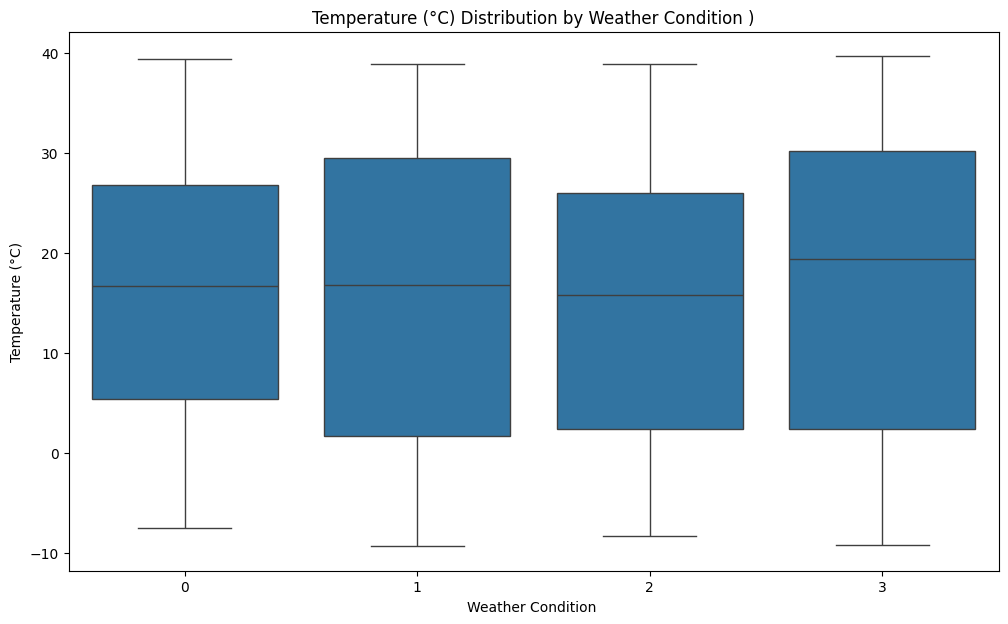

In [32]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Weather Condition', y='Temperature (°C)', data=df)
plt.title('Temperature (°C) Distribution by Weather Condition )')
plt.xlabel('Weather Condition ')
plt.ylabel('Temperature (°C)')
plt.show()